# Notebook 05 – Advanced Analysis

**Goal:** group Italian municipalities by accident profile (clustering) and test whether the differences between groups are statistically significant.

**Reference year:** 2023 for all analyses (last complete year).

**Data:** `Data/Processed/integrated_clean.csv`

**1. Prepare the data** 
* Load the integrated table and filter to 2023, matched municipalities with valid rates. The two features for clustering are `accidents_per_1000` (risk per inhabitant) and `accidents_per_km2` (spatial concentration of accidents).

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import statsmodels.api as sm

df = pd.read_csv("Data/Processed/integrated_clean.csv", keep_default_na=False, na_values=[""])

df_2023 = df[
    (df["TIME_PERIOD"] == 2023) &
    (df["Comune"].notna()) &
    (df["accidents_per_1000"].notna()) &
    (df["accidents_per_km2"].notna())
].copy()

print("Municipalities for clustering:", len(df_2023)) 

Municipalities for clustering: 7892


**2. Scaling and optimal number of clusters** –
* The two features (`accidents_per_1000` and `accidents_per_km2`) are scaled to the same range with `StandardScaler` before clustering, so neither dominates. The elbow method plots the inertia for k = 1 to 10: the optimal k is where the curve bends (the "elbow").

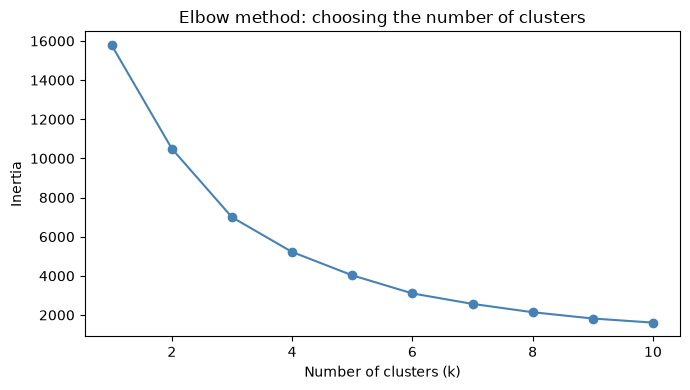

In [ ]:
features = df_2023[["accidents_per_1000", "accidents_per_km2"]].copy()
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), inertia, marker="o", color="steelblue")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method: choosing the number of clusters")
plt.tight_layout()
plt.show()

**3. KMeans clustering (k=4)** 
* Four clusters chosen from the elbow plot. The centroids show the average accident rates for each group, back in the original scale. Most municipalities fall in the low-rate cluster.

In [21]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df_2023["cluster"] = km.fit_predict(features_scaled)

print(df_2023["cluster"].value_counts().sort_index())

centroids = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=["accidents_per_1000", "accidents_per_km2"]
).round(2)
centroids.index.name = "cluster"
print(centroids)

cluster
0    5138
1     154
2    2532
3      68
Name: count, dtype: int64
         accidents_per_1000  accidents_per_km2
cluster                                       
0                      0.83               0.17
1                      3.86               9.58
2                      3.24               0.98
3                     13.35               0.58


0	5.138	0,83	0,17	basso rischio (la maggioranza)
1	154	3,86	9,58	alta densità (città compatte, cintura milanese)
2	2.532	3,24	0,98	rischio medio (città medie)
3	68	13,35	0,58	alto tasso per abitante (città turistiche, Lavagna, Finale Ligure)

**4. Cluster visualization** 
* Scatter plot coloured by cluster. The axes are cut at 10 and 15 to zoom in on the bulk of municipalities: extreme outliers (e.g. Milano at 42 per km²) are outside the plot but visible in the centroid table.

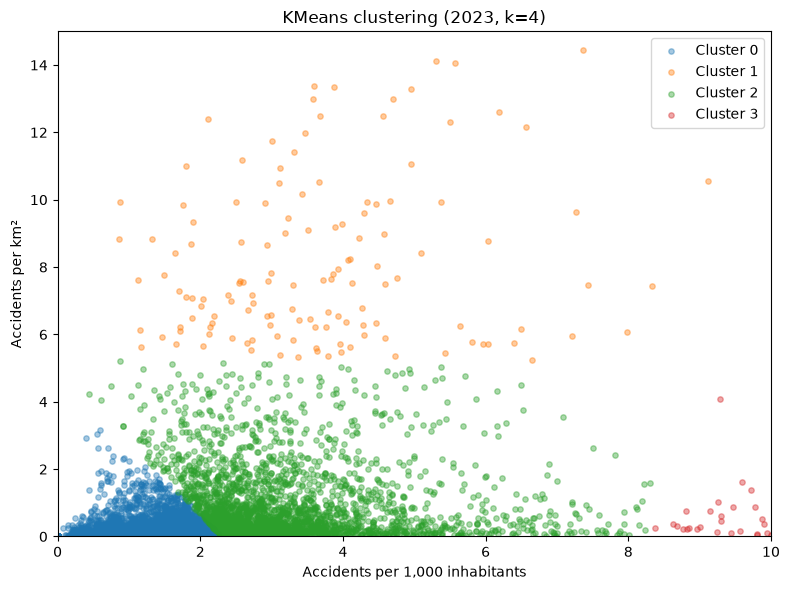

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

for cluster_id, group in df_2023.groupby("cluster"):
    ax.scatter(
        group["accidents_per_1000"],
        group["accidents_per_km2"],
        alpha=0.4, s=15,
        label=f"Cluster {cluster_id}"
    )

ax.set_xlabel("Accidents per 1,000 inhabitants")
ax.set_ylabel("Accidents per km²")
ax.set_title("KMeans clustering (2023, k=4)")
ax.set_xlim(0, 10)      # zoom: cut extreme outliers on x
ax.set_ylim(0, 15)      # zoom: cut extreme outliers on y
ax.legend()
plt.tight_layout()
plt.show()

**5. Representative municipalities per cluster** 
* The 3 municipalities with the most accidents in each cluster. Confirms the cluster interpretation: cluster 0 = small low-risk towns; cluster 1 = dense urban areas (Milan belt); cluster 2 = medium cities; cluster 3 = high rate per inhabitant relative to population.

In [25]:
examples = []
for c in sorted(df_2023["cluster"].unique()):
    top3 = df_2023[df_2023["cluster"] == c].sort_values("accidents", ascending=False).head(3)
    top3 = top3[["cluster", "Comune", "accidents_per_1000", "accidents_per_km2", "Popolazione residente"]]
    examples.append(top3)

examples = pd.concat(examples, ignore_index=True)
print(examples.to_string())

    cluster              Comune  accidents_per_1000  accidents_per_km2  Popolazione residente
0         0              Andria            1.798450           0.431888                  96750
1         0            Altamura            2.023859           0.329184                  70163
2         0           Catanzaro            1.680410           1.241327                  83313
3         1                Roma            4.665325           9.949639                2747290
4         1              Milano            5.720152          42.959663                1365698
5         1              Genova            6.504397          15.245942                 564080
6         2  Reggio nell'Emilia            4.655104           3.476672                 172284
7         2             Ravenna            4.861200           1.162658                 156340
8         2               Parma            3.799832           2.897185                 198693
9         3  Lignano Sabbiadoro            9.291521         

**6. Linear regression: population density vs accident rate per km²**

* **H₀:** no relationship between density and accident rate per km² (slope = 0).
* **H₁:** denser municipalities have higher accident rates per km².
* **Result:** slope = 0.002 (p < 0.001), R² = 0.669. We reject H₀: population density is a statistically significant predictor of the spatial concentration of accidents, explaining 67% of the variance.
    * Every additional 100 inhabitants per km² adds about 0.2 accidents per km².
    * Top 1% outliers removed to avoid extreme cities dominating the fit.


In [29]:
import statsmodels.api as sm

# calculate population density
df_2023["density"] = df_2023["Popolazione residente"] / df_2023["Superficie (Kmq)"]

# remove top 1% outliers
threshold_density = df_2023["density"].quantile(0.99)
threshold_km2 = df_2023["accidents_per_km2"].quantile(0.99)
df_reg = df_2023[
    (df_2023["density"] < threshold_density) &
    (df_2023["accidents_per_km2"] < threshold_km2)
].copy()

# fit the model: does density predict the accident rate per km²?
Y = df_reg["accidents_per_km2"]
X = sm.add_constant(df_reg["density"])
model = sm.OLS(endog=Y, exog=X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      accidents_per_km2   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.669
Method:                 Least Squares   F-statistic:                 1.573e+04
Date:                Sun, 04 Oct 2026   Prob (F-statistic):               0.00
Time:                        22:56:50   Log-Likelihood:                -6008.7
No. Observations:                7774   AIC:                         1.202e+04
Df Residuals:                    7772   BIC:                         1.204e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.007      0.043      0.966      -0.014       0.014
density        0.0020   1.56e-05    125.420      0.000       0.002       0.002
==============================================================================
Omnibus:                     3763.806   Durbin-Watson:                   1.880
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           155524.451
Skew:                           1.627   Prob(JB):                         0.00
Kurtosis:                      24.669   Cond. No.                         537.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

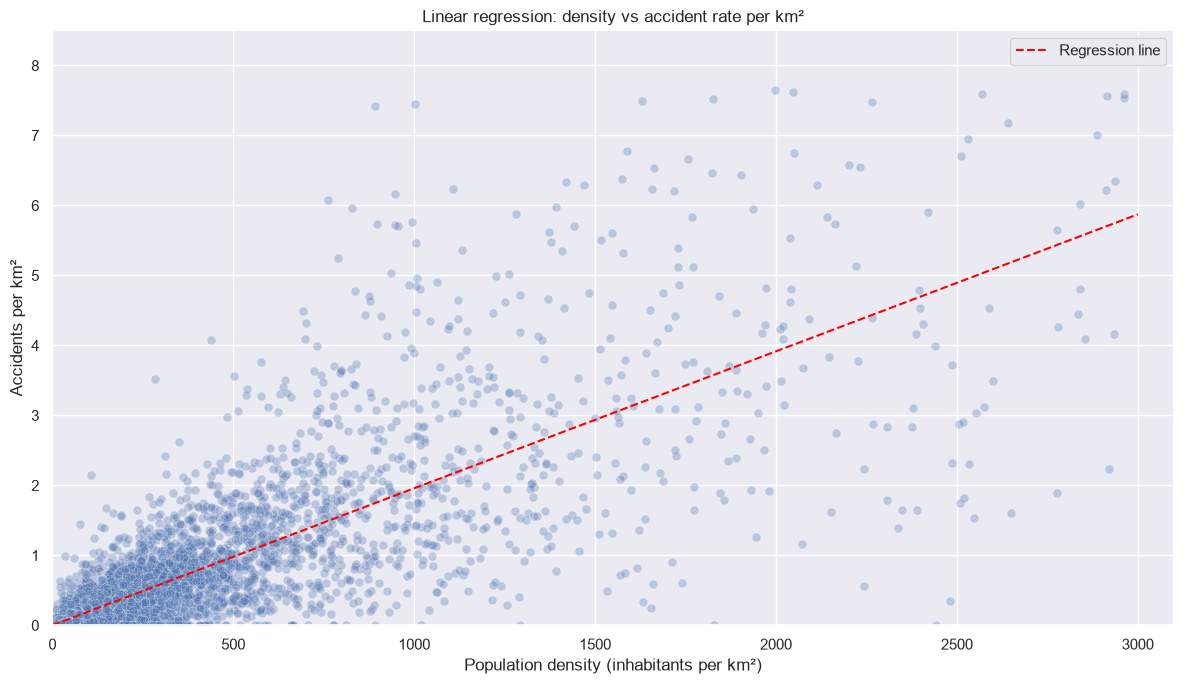

In [50]:
sns.set_theme(rc={"figure.figsize": (12, 7)})
sns.scatterplot(
    x="density",
    y="accidents_per_km2",
    data=df_reg,
    alpha=0.3,
    s=40, 
)
x_vals = np.array([0, 3000])  
y_vals = results.params["const"] + results.params["density"] * x_vals
import matplotlib.pyplot as plt

plt.plot(x_vals, y_vals, "--", color="red", label="Regression line")

plt.xlim(0, 3100)  
plt.ylim(0, 8.5)  

plt.xlabel("Population density (inhabitants per km²)")
plt.ylabel("Accidents per km²")
plt.title("Linear regression: density vs accident rate per km²")
plt.legend()
plt.tight_layout()
plt.show()
